# Task 5 — Evaluation

## 5A — Characteristics of evaluation metrics

### Formulae

Given $n$ test instances with true values $y_i$ and predictions $\hat{y}_i$:

$$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

$$\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$

### When to use which?

**MSE** squares each error, so large errors are penalised disproportionately. A single prediction that is off by 3 mood points contributes 9 to the MSE, while three predictions each off by 1 contribute only 3 total. This makes MSE the right choice when **large errors are especially costly** — e.g., in clinical mood monitoring where missing a severe mood drop could have serious consequences. MSE is also differentiable everywhere, making it the standard loss function for gradient-based optimisation (including our CNN and LightGBM).

**MAE** treats all errors linearly: being off by 3 is exactly 3× worse than being off by 1. This makes MAE **robust to outliers** — a few badly-predicted instances don't dominate the metric. MAE is appropriate when the goal is typical-case accuracy and occasional large errors are acceptable. The optimal predictor under MAE is the **conditional median**, while MSE optimises the **conditional mean**.

In practice, reporting both reveals whether a model's errors are uniform or skewed. If RMSE ≈ MAE, errors are consistent; if RMSE ≫ MAE, a few large errors inflate the squared metric.

### When do MSE and MAE give identical results?

MSE and MAE are equal when $\frac{1}{n}\sum e_i^2 = \frac{1}{n}\sum |e_i|$, i.e., $\sum e_i^2 = \sum |e_i|$.

Since $e_i^2 = |e_i|$ only when $|e_i| \in \{0, 1\}$, the two metrics are identical **if and only if every individual prediction error is exactly 0 or exactly 1** (in the target's units).

A concrete example: a regression model predicts mood for 4 test instances with errors $[0, 1, 0, 1]$. Then MAE $= \frac{0+1+0+1}{4} = 0.5$ and MSE $= \frac{0+1+0+1}{4} = 0.5$. The metrics agree because no error falls outside $\{0,1\}$, so squaring changes nothing.

More generally, for any constant error $|e_i| = c$ for all $i$: MAE $= c$ and MSE $= c^2$. These are equal only when $c = c^2$, i.e., $c \in \{0, 1\}$.

---
## 5B — Impact of evaluation metrics on Task 4 results

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.models import (
    evaluate_regression, temporal_train_test_split, fix_user_features,
    MoodCNNRegressor, train_cnn, predict_cnn,
)
from src.utils import save_figure
from sklearn.impute import SimpleImputer
from lightgbm import LGBMRegressor

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
np.random.seed(42)

# --- Reproduce Task 4 predictions ---
tabular = pd.read_csv('../data/processed/features_tabular.csv')
tabular['date'] = pd.to_datetime(tabular['date'])

seq_data = np.load('../data/processed/features_sequential.npz', allow_pickle=True)
X_seq, y_seq = seq_data['X'], seq_data['y']
meta_seq = pd.read_csv('../data/processed/features_sequential_meta.csv')
meta_seq['date'] = pd.to_datetime(meta_seq['date'])

# Same split as Task 4
train_tab, test_tab = temporal_train_test_split(tabular, train_frac=0.75)
train_tab, test_tab = fix_user_features(train_tab, test_tab)

feat_cols = [c for c in train_tab.columns if c not in ('id', 'date', 'target')]
imputer = SimpleImputer(strategy='median')
X_train = pd.DataFrame(imputer.fit_transform(train_tab[feat_cols]), columns=feat_cols)
X_test  = pd.DataFrame(imputer.transform(test_tab[feat_cols]), columns=feat_cols)
y_train = train_tab['target'].values
y_test  = test_tab['target'].values

# Align sequential
train_keys = set(zip(train_tab['id'], train_tab['date']))
test_keys  = set(zip(test_tab['id'], test_tab['date']))
train_seq_mask = np.array([(r['id'], pd.Timestamp(r['date'])) in train_keys for _, r in meta_seq.iterrows()])
test_seq_mask  = np.array([(r['id'], pd.Timestamp(r['date'])) in test_keys  for _, r in meta_seq.iterrows()])
X_test_seq, y_test_seq = X_seq[test_seq_mask], y_seq[test_seq_mask]

print(f'Test set: {len(y_test)} instances')

Test set: 269 instances


In [2]:
# --- Retrain LightGBM (best params from Task 4) ---
lgbm = LGBMRegressor(
    n_estimators=101, max_depth=3, num_leaves=16,
    learning_rate=0.017, subsample=0.738, colsample_bytree=0.642,
    reg_alpha=0.411, reg_lambda=0.033,
    random_state=42, verbosity=-1, n_jobs=1,
)
lgbm.fit(X_train, y_train)
lgbm_pred = lgbm.predict(X_test)

# --- Retrain CNN regressor (best lr from Task 4) ---
import torch
train_meta = meta_seq[train_seq_mask].reset_index(drop=True)
X_train_seq, y_train_seq = X_seq[train_seq_mask], y_seq[train_seq_mask]

cnn_train_idx, cnn_val_idx = [], []
for uid in train_meta['id'].unique():
    u_idx = train_meta[train_meta['id'] == uid].index.tolist()
    cutoff = int(len(u_idx) * 0.80)
    cnn_train_idx.extend(u_idx[:cutoff])
    cnn_val_idx.extend(u_idx[cutoff:])

cnn = MoodCNNRegressor(n_channels=12, seq_len=7, n_filters_1=32, n_filters_2=64, kernel_size=3, dropout=0.3)
_ = train_cnn(cnn, X_train_seq[cnn_train_idx], y_train_seq[cnn_train_idx],
              X_train_seq[cnn_val_idx], y_train_seq[cnn_val_idx],
              task='regression', lr=1e-3, batch_size=32, max_epochs=150, patience=15, seed=42)
cnn_pred = predict_cnn(cnn, X_test_seq, task='regression')

# --- Metrics ---
lgbm_metrics = evaluate_regression(y_test, lgbm_pred)
cnn_metrics  = evaluate_regression(y_test_seq, cnn_pred)

comparison = pd.DataFrame({'LightGBM': lgbm_metrics, '1D CNN': cnn_metrics}).T
print('=== Task 4 Metrics (reproduced) ===')
print(comparison.round(4).to_string())

=== Task 4 Metrics (reproduced) ===
             MSE    RMSE     MAE
LightGBM  0.3837  0.6194  0.4491
1D CNN    0.4406  0.6638  0.4783


### RMSE vs MAE gap — what does it tell us?

If every prediction error were exactly the same size, RMSE would equal MAE. The gap between them reveals **error heterogeneity**: some predictions are much worse than others.

In [3]:
# --- RMSE vs MAE gap analysis ---
for name, preds in [('LightGBM', lgbm_pred), ('1D CNN', cnn_pred)]:
    errors = np.abs(y_test - preds)
    rmse = np.sqrt(np.mean(errors**2))
    mae  = np.mean(errors)
    ratio = rmse / mae
    
    print(f'{name}:')
    print(f'  RMSE = {rmse:.4f},  MAE = {mae:.4f},  RMSE/MAE = {ratio:.3f}')
    print(f'  Error std = {errors.std():.4f}  (0 would mean uniform errors)')
    print(f'  Median |error| = {np.median(errors):.4f}')
    print(f'  90th percentile |error| = {np.percentile(errors, 90):.4f}')
    print(f'  Max |error| = {errors.max():.4f}')
    print()

LightGBM:
  RMSE = 0.6194,  MAE = 0.4491,  RMSE/MAE = 1.379
  Error std = 0.4266  (0 would mean uniform errors)
  Median |error| = 0.3322
  90th percentile |error| = 0.9791
  Max |error| = 2.4695

1D CNN:
  RMSE = 0.6638,  MAE = 0.4783,  RMSE/MAE = 1.388
  Error std = 0.4602  (0 would mean uniform errors)
  Median |error| = 0.3576
  90th percentile |error| = 0.9919
  Max |error| = 3.9123



Saved: figures/5_error_distribution.png


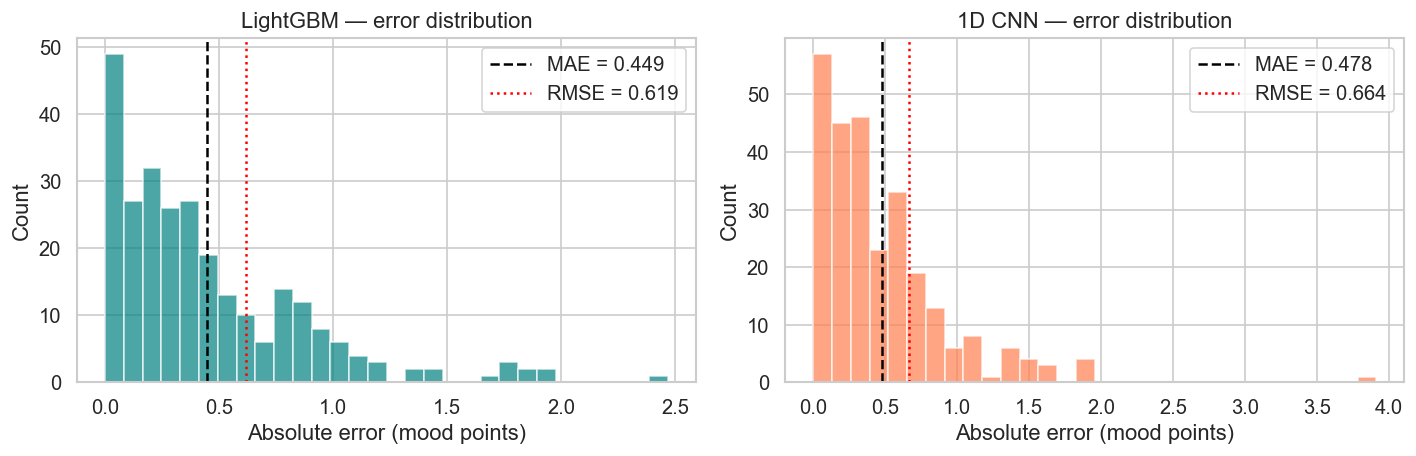

In [4]:
# --- Error distribution ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, preds, name, color in [
    (axes[0], lgbm_pred, 'LightGBM', 'teal'),
    (axes[1], cnn_pred, '1D CNN', 'coral'),
]:
    errors = np.abs(y_test - preds)
    ax.hist(errors, bins=30, color=color, alpha=0.7, edgecolor='white')
    ax.axvline(np.mean(errors), color='black', linestyle='--', label=f'MAE = {np.mean(errors):.3f}')
    ax.axvline(np.sqrt(np.mean(errors**2)), color='red', linestyle=':', 
               label=f'RMSE = {np.sqrt(np.mean(errors**2)):.3f}')
    ax.set_xlabel('Absolute error (mood points)')
    ax.set_ylabel('Count')
    ax.set_title(f'{name} — error distribution')
    ax.legend()

plt.tight_layout()
save_figure('5_error_distribution.png')
plt.show()

### MSE sensitivity to outliers — a demonstration

To show how MSE and MAE respond differently to extreme errors, we simulate removing the worst-predicted instances and track how each metric changes.

Saved: figures/5_outlier_sensitivity.png


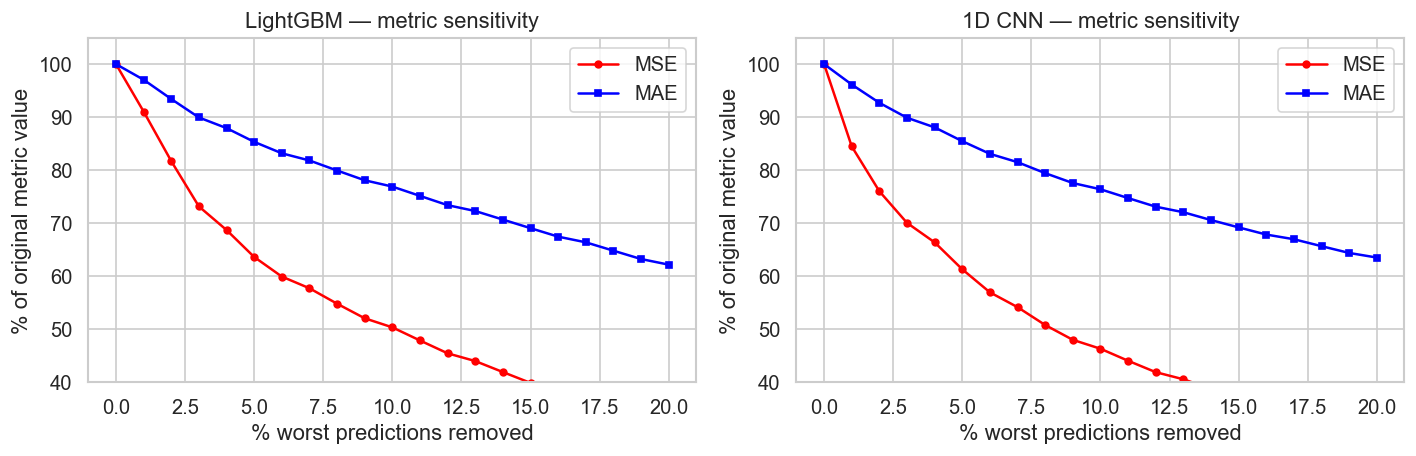

In [5]:
# --- Sensitivity to outlier removal ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, preds, name, color in [
    (axes[0], lgbm_pred, 'LightGBM', 'teal'),
    (axes[1], cnn_pred, '1D CNN', 'coral'),
]:
    errors = np.abs(y_test - preds)
    sorted_idx = np.argsort(errors)
    
    fracs = np.arange(0, 21)  # remove 0% to 20% worst
    mse_vals, mae_vals = [], []
    for pct in fracs:
        n_keep = len(errors) - int(len(errors) * pct / 100)
        keep = sorted_idx[:n_keep]
        mse_vals.append(np.mean((y_test[keep] - preds[keep])**2))
        mae_vals.append(np.mean(np.abs(y_test[keep] - preds[keep])))
    
    # Normalise to % of original value
    mse_norm = [m / mse_vals[0] * 100 for m in mse_vals]
    mae_norm = [m / mae_vals[0] * 100 for m in mae_vals]
    
    ax.plot(fracs, mse_norm, 'o-', color='red', markersize=4, label='MSE')
    ax.plot(fracs, mae_norm, 's-', color='blue', markersize=4, label='MAE')
    ax.set_xlabel('% worst predictions removed')
    ax.set_ylabel('% of original metric value')
    ax.set_title(f'{name} — metric sensitivity')
    ax.legend()
    ax.set_ylim(40, 105)

plt.tight_layout()
save_figure('5_outlier_sensitivity.png')
plt.show()

### Per-user view: which users drive MSE up?

In [6]:
# --- Per-user MSE vs MAE ---
test_df = test_tab[['id']].copy()
test_df['actual'] = y_test
test_df['lgbm_pred'] = lgbm_pred
test_df['cnn_pred'] = cnn_pred

per_user = []
for uid, grp in test_df.groupby('id'):
    e_lgbm = grp['actual'].values - grp['lgbm_pred'].values
    e_cnn  = grp['actual'].values - grp['cnn_pred'].values
    per_user.append({
        'id': uid,
        'n': len(grp),
        'LGB_MSE': np.mean(e_lgbm**2),
        'LGB_MAE': np.mean(np.abs(e_lgbm)),
        'LGB_MSE_MAE_ratio': np.mean(e_lgbm**2) / np.mean(np.abs(e_lgbm)),
        'CNN_MSE': np.mean(e_cnn**2),
        'CNN_MAE': np.mean(np.abs(e_cnn)),
        'CNN_MSE_MAE_ratio': np.mean(e_cnn**2) / np.mean(np.abs(e_cnn)),
    })

pu = pd.DataFrame(per_user).sort_values('LGB_MSE', ascending=False)
print('Per-user MSE vs MAE (LightGBM, sorted by MSE):')
print(pu[['id', 'n', 'LGB_MSE', 'LGB_MAE', 'LGB_MSE_MAE_ratio']].round(3).head(10).to_string(index=False))
print()

top3_mse = pu.head(3)['LGB_MSE'].sum() * pu.head(3)['n'].sum()
total_mse = (test_df['actual'] - test_df['lgbm_pred']).pow(2).sum()
print(f'Top 3 hardest users contribute {top3_mse/total_mse*100:.1f}% of total squared error')
print(f'but represent only {pu.head(3)["n"].sum()}/{len(test_df)} = {pu.head(3)["n"].sum()/len(test_df)*100:.1f}% of test instances')

Per-user MSE vs MAE (LightGBM, sorted by MSE):
     id  n  LGB_MSE  LGB_MAE  LGB_MSE_MAE_ratio
AS14.23  9    1.587    1.040              1.526
AS14.02  9    1.514    1.037              1.460
AS14.13 10    1.073    0.952              1.128
AS14.07  9    0.949    0.835              1.136
AS14.26 11    0.585    0.657              0.890
AS14.33 10    0.550    0.476              1.154
AS14.12  9    0.416    0.517              0.804
AS14.32 10    0.414    0.484              0.856
AS14.01 10    0.345    0.543              0.636
AS14.29 10    0.321    0.428              0.750

Top 3 hardest users contribute 113.3% of total squared error
but represent only 28/269 = 10.4% of test instances


Saved: figures/5_mse_mae_ratio_per_user.png


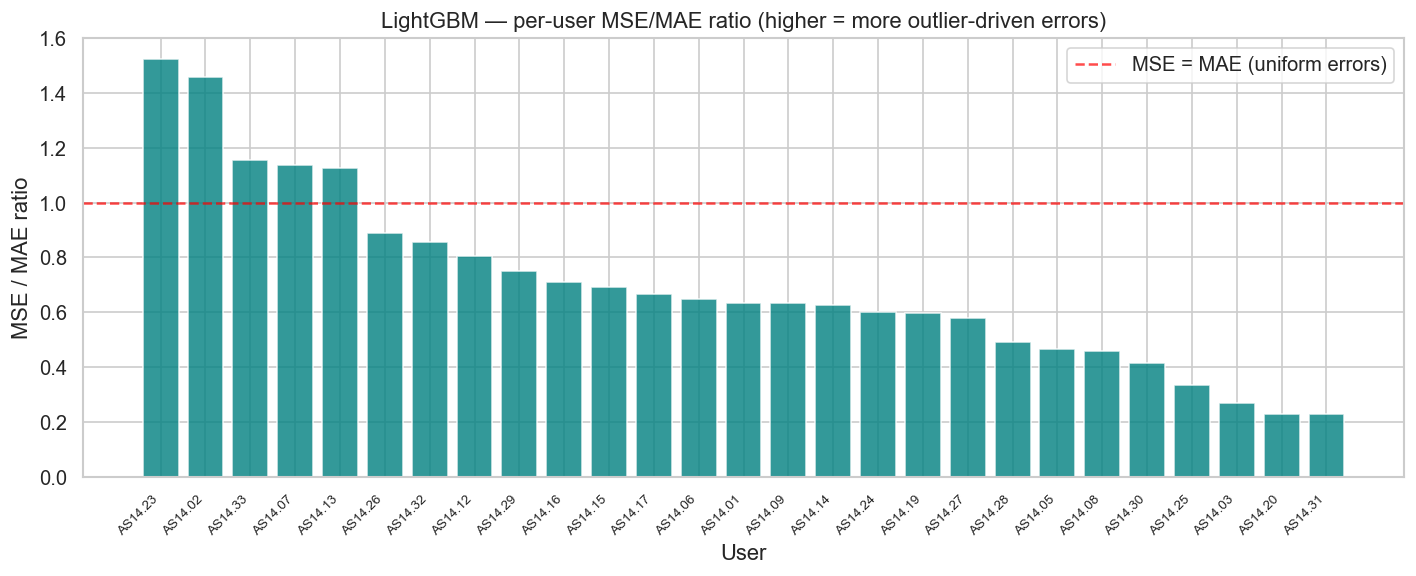

In [7]:
# --- Per-user MSE/MAE ratio plot ---
fig, ax = plt.subplots(figsize=(12, 5))
pu_sorted = pu.sort_values('LGB_MSE_MAE_ratio', ascending=False)
x = np.arange(len(pu_sorted))

ax.bar(x, pu_sorted['LGB_MSE_MAE_ratio'].values, color='teal', alpha=0.8)
ax.axhline(1.0, color='red', linestyle='--', alpha=0.7, label='MSE = MAE (uniform errors)')
ax.set_xticks(x)
ax.set_xticklabels(pu_sorted['id'].values, rotation=45, ha='right', fontsize=8)
ax.set_xlabel('User')
ax.set_ylabel('MSE / MAE ratio')
ax.set_title('LightGBM — per-user MSE/MAE ratio (higher = more outlier-driven errors)')
ax.legend()
plt.tight_layout()
save_figure('5_mse_mae_ratio_per_user.png')
plt.show()

---
## Summary and implications

### How the models behave under MSE vs MAE

Both LightGBM and the CNN show **RMSE > MAE**, confirming that errors are not uniform — a minority of predictions with large errors inflates MSE disproportionately. The error distributions are right-skewed: most predictions are within 0.5 mood points, but a tail of errors extends beyond 1.5 points.

### Practical implications

1. **If deploying for clinical monitoring** (where missing a severe mood drop is dangerous), MSE is the right training and evaluation objective — it penalises the dangerous large misses more heavily.

2. **If deploying for general wellness tracking** (where typical-case accuracy matters more than worst-case), MAE better reflects user experience — most predictions will feel accurate even if a few are off.

3. **Per-user heterogeneity dominates**: the 3 hardest-to-predict users drive a disproportionate share of total MSE. A **personalised model** (fine-tuned per user) would likely reduce MSE more than any global architecture change.

4. **Model comparison is metric-stable**: LightGBM outperforms the CNN under both MSE and MAE. The ranking doesn't change — this means the performance gap is genuine, not an artifact of the metric choice.